<a href="https://colab.research.google.com/github/gshaurya27/SOC-26---Face-Ageing-Model/blob/main/WEEK%203/CNN_imp_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


In [14]:
#load data
X_train = np.loadtxt('input.csv' , delimiter=',')
Y_train = np.loadtxt('labels.csv' , delimiter=',')

X_test = np.loadtxt('input_test.csv' , delimiter=',')
Y_test = np.loadtxt('labels_test.csv' , delimiter=',')


In [15]:
X_train = (X_train.reshape(len(X_train), 100, 100, 3))/255
X_test = (X_test.reshape(len(X_test), 100, 100, 3))/255

Y_train = Y_train.reshape(len(Y_train), 1)
Y_test = Y_test.reshape(len(Y_test), 1)



In [16]:
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print('X_test shape:', X_test.shape)
print('Y_test shape:', Y_test.shape)

X_train shape: (2000, 100, 100, 3)
Y_train shape: (2000, 1)
X_test shape: (400, 100, 100, 3)
Y_test shape: (400, 1)


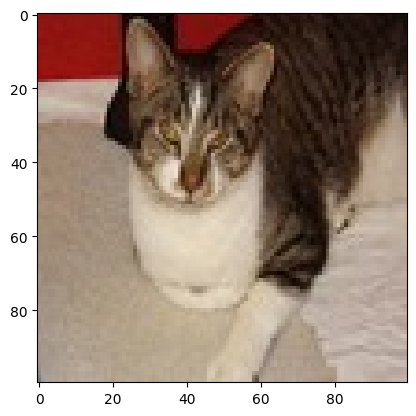

In [17]:
idx = random.randint(0, len(X_train))
plt.imshow(X_train[idx, :])
plt.show()

In [19]:
model = Sequential([
    Conv2D(32, (3, 3),activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
      ]
                   )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt ,loss='binary_crossentropy',metrics=['accuracy'])

In [26]:
model.fit(X_train , Y_train , epochs=10 , batch_size=32)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 386ms/step - accuracy: 0.5185 - loss: 0.6963
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 401ms/step - accuracy: 0.6325 - loss: 0.6482
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 385ms/step - accuracy: 0.7130 - loss: 0.5750
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 641ms/step - accuracy: 0.7550 - loss: 0.4956
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 384ms/step - accuracy: 0.8275 - loss: 0.4015
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 443ms/step - accuracy: 0.8540 - loss: 0.3196
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 406ms/step - accuracy: 0.9045 - loss: 0.2367
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 366ms/step - accuracy: 0.9450 - loss: 0.1600
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 404ms/step - accuracy: 0.9645 - loss: 0.1074
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 406ms/step - accuracy: 0.9720 - loss: 0.0835


In [27]:
model.evaluate(X_test , Y_test)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.6575 - loss: 1.3884


[1.3884093761444092, 0.6575000286102295]

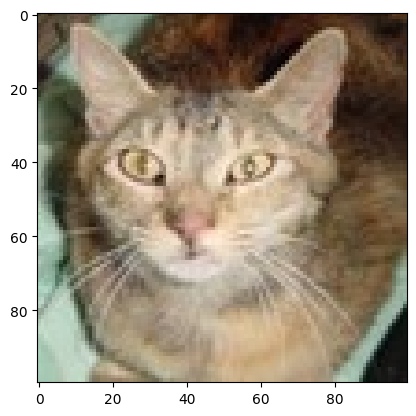

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Cat


In [41]:
idx2 = random.randint(0, len(X_test))
plt.imshow(X_test[idx2, :])
plt.show()

y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100, 3))
y_pred = y_pred > 0.5

if y_pred == 0:
    print('Dog')
else:
    print('Cat')